# 🛡️ CYBERSECURITY ATTACK PATH VISUALIZATION SYSTEM  
##  AI-Based Graph Search Algorithms Simulator

---

> “Modeling network security as intelligent graph traversal for attack detection and path optimization.”

---

## 📌 📄 PROJECT REPORT (LAB MID SUBMISSION)

---

### 🎓 Academic Information

- **Course Title:** _____Artificial Intelligence_____
- **Course Code:** _____CSC 262_____
- **Submitted By:** _________NIDARIAZ AND HANIA KHAN_________  
- **Roll Number:** _______FA24-BCS-128 &FA24-BCS-116_______  
- **Department:** _________Computer Science_________    
- **Institution:** _________CUI ATD_________  

---

### 👨‍🏫 Supervision

**Submitted To:**  
__________________Ma'am Zeenat Zulfiqar__________________

---

### 📅 Submission Details

- **Submission Date:** 30 May 2026  
- **Session:** Spring 2026  
- **Type:** Lab Mid Project  

---

## 🚀 Project Abstract

This project presents a **graph-based cybersecurity simulation system** that models a computer network as an interconnected graph of nodes (systems) and edges (connections).  

It applies **AI search algorithms** to analyze possible attack paths an adversary may take to reach sensitive systems.

The system visually demonstrates:

- Breadth First Search (BFS)
- Depth First Search (DFS)
- A* Algorithm
- UCS
- Hill Climbing
- Node traversal behavior
- Attack propagation in a network

The goal is to improve understanding of **pathfinding algorithms in cybersecurity threat analysis**.

---

##  Core Concepts Implemented

✔ Graph Theory Modeling  
✔ AI Search Algorithms  
✔ Attack Path Simulation  
✔ Step-by-step Node Traversal  
✔ Real-time Visualization (Canvas-based)

---

## 💻 Technologies Used

- HTML5 (Structure)
- CSS3 (UI Styling)
- JavaScript (Algorithm Logic)
- Canvas API (Graph Rendering)
- Network Modeling Concepts
- Google Colab

---

## 🎯 Project Objectives

- To simulate real-world cyber network structures  
- To apply BFS & DFS in security analysis  
- To visualize algorithm behavior dynamically  
- To understand attack path discovery techniques  

---

## 📊 Expected Output

- Interactive graph visualization  
- Step-by-step traversal animation  
- Highlighted nodes during execution  
- Clear attack path representation  

---

## 🧩 System Insight

> This project bridges Artificial Intelligence and Cybersecurity by demonstrating how search algorithms can be used to analyze vulnerabilities in network systems.

---

## 🚀 Live System Access

> BFS, DFS, A* and UCS Implementation (Graph-Based AI Simulation)

🔗 **Launch Project → [Cybersecurity AI Graph Simulator](https://algorithms-implementatiom-c49877.netlify.app/)**

> MinMax and Alpha Beta Prunning  

🔗 **Launch Project → [Cybersecurity AI Graph Simulator](https://alphabeta-minmax-19d5f990.netlify.app/)**

# Libraries

---



In [124]:
!pip install networkx matplotlib pandas

In [125]:
%matplotlib inline

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq
import time
import pandas as pd

# Cybersecurity Attack Network Graph

---



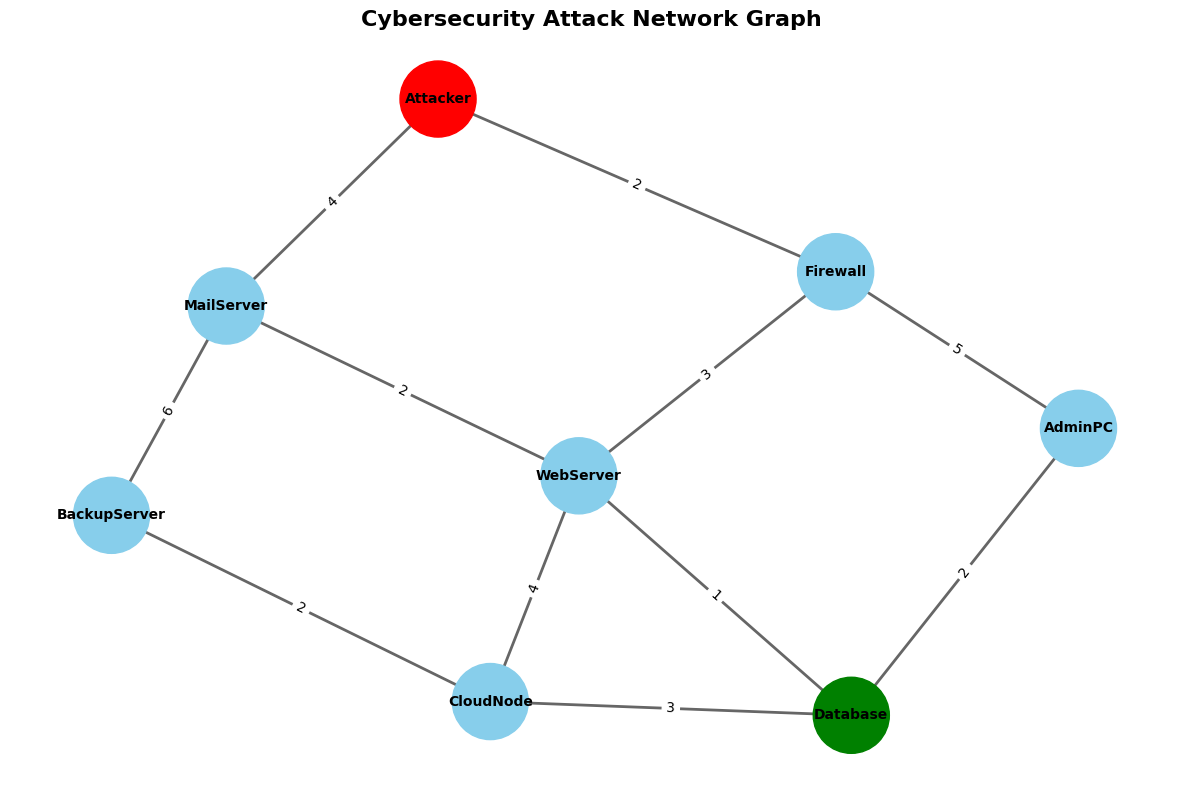

In [129]:
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------
# Create Cyber Security Network
# -------------------------
G = nx.Graph()

edges = [
    ("Attacker", "Firewall", 2),
    ("Attacker", "MailServer", 4),
    ("Firewall", "WebServer", 3),
    ("Firewall", "AdminPC", 5),
    ("MailServer", "WebServer", 2),
    ("MailServer", "BackupServer", 6),
    ("WebServer", "Database", 1),
    ("WebServer", "CloudNode", 4),
    ("AdminPC", "Database", 2),
    ("BackupServer", "CloudNode", 2),
    ("CloudNode", "Database", 3)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)
    start = "Attacker"
goal = "Database"

# -------------------------
# Layout (professional look)
# -------------------------
pos = nx.spring_layout(G, seed=42)

# -------------------------
# Node Styling
# -------------------------
node_colors = []
for node in G.nodes():
    if node == "Attacker":
        node_colors.append("red")
    elif node == "Database":
        node_colors.append("green")
    else:
        node_colors.append("skyblue")

# -------------------------
# Draw Graph
# -------------------------
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# -------------------------
# Title
# -------------------------
plt.title("Cybersecurity Attack Network Graph ", fontsize=16, fontweight="bold")

plt.axis("off")
plt.tight_layout()
plt.show()

# BFS Implementation

---



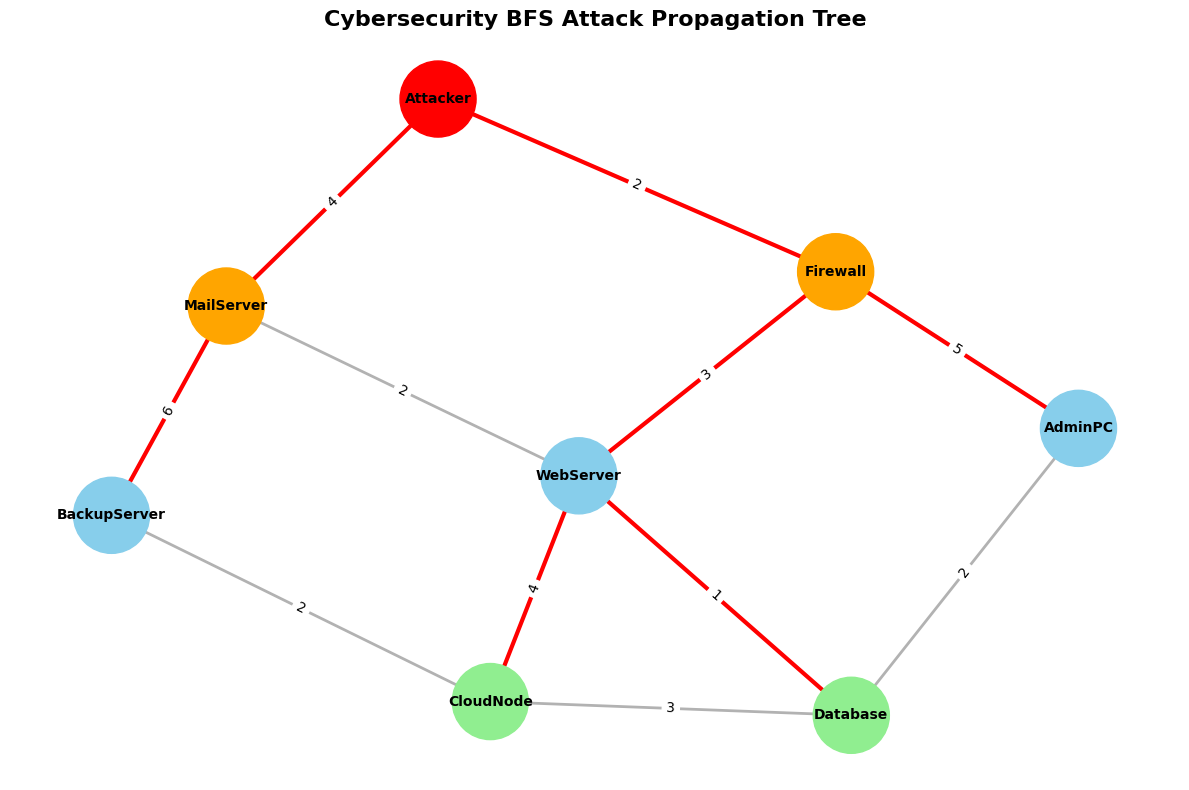

BFS Traversal Order from Attacker:
Attacker -> Firewall -> MailServer -> WebServer -> AdminPC -> BackupServer -> Database -> CloudNode


In [130]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# -------------------------
# Create Cyber Security Network
# -------------------------
G = nx.Graph()

edges = [
    ("Attacker", "Firewall", 2),
    ("Attacker", "MailServer", 4),
    ("Firewall", "WebServer", 3),
    ("Firewall", "AdminPC", 5),
    ("MailServer", "WebServer", 2),
    ("MailServer", "BackupServer", 6),
    ("WebServer", "Database", 1),
    ("WebServer", "CloudNode", 4),
    ("AdminPC", "Database", 2),
    ("BackupServer", "CloudNode", 2),
    ("CloudNode", "Database", 3)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# -------------------------
# BFS Implementation
# -------------------------
start_node = "Attacker"

visited = set()
level = {start_node: 0}
parent = {}

queue = deque([start_node])
visited.add(start_node)

while queue:
    node = queue.popleft()

    for neighbor in G.neighbors(node):
        if neighbor not in visited:
            visited.add(neighbor)
            queue.append(neighbor)
            level[neighbor] = level[node] + 1
            parent[neighbor] = node

# -------------------------
# BFS Tree Edges
# -------------------------
bfs_edges = [(parent[n], n) for n in parent]

# -------------------------
# Layout
# -------------------------
pos = nx.spring_layout(G, seed=42)

# -------------------------
# Node Colors by BFS Level
# -------------------------
color_map = []
for node in G.nodes():
    if node == start_node:
        color_map.append("red")          # Attacker
    elif node not in level:
        color_map.append("gray")
    else:
        # gradient effect by level
        if level[node] == 1:
            color_map.append("orange")
        elif level[node] == 2:
            color_map.append("skyblue")
        else:
            color_map.append("lightgreen")

# -------------------------
# Draw Graph
# -------------------------
plt.figure(figsize=(12, 8))

# All edges (background network)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=2)

# BFS tree edges (highlighted)
nx.draw_networkx_edges(G, pos, edgelist=bfs_edges, edge_color="red", width=3)

# Nodes
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=3000)

# Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Edge weights
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# -------------------------
# Title
# -------------------------
plt.title("Cybersecurity BFS Attack Propagation Tree", fontsize=16, fontweight="bold")

plt.axis("off")
plt.tight_layout()
plt.show()

# -------------------------
# Print BFS Order
# -------------------------
print("BFS Traversal Order from Attacker:")
print(" -> ".join(list(level.keys())))

# DFS Implementation

---



========== DFS RESULT ==========
Discovered Path: Attacker → Firewall → AdminPC → Database
Total Cost: 9
Nodes Expanded: 4
Execution Time (ms): 0.4981


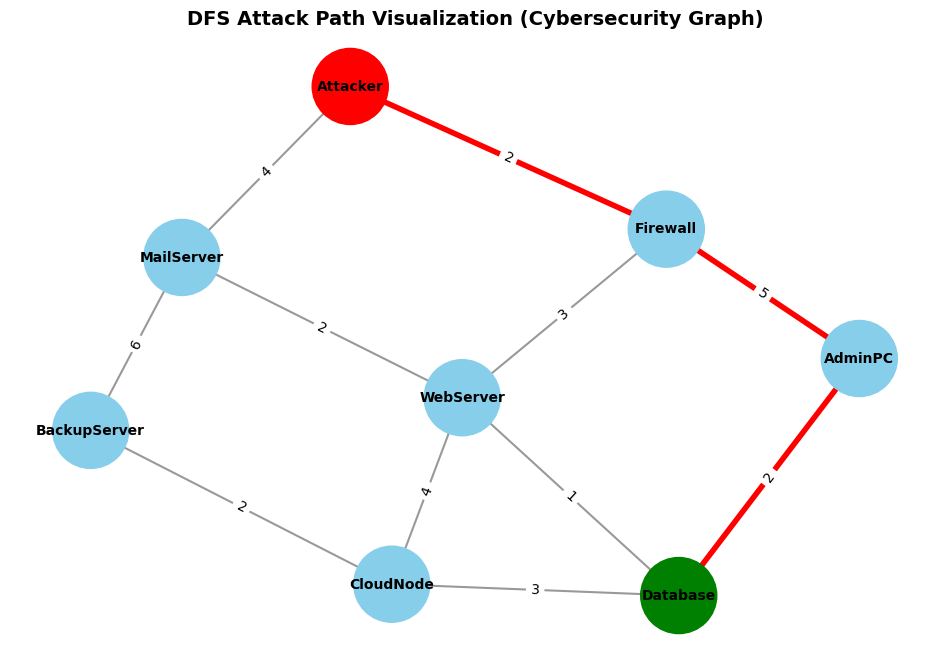

In [131]:
import networkx as nx
import matplotlib.pyplot as plt
import time
# Create Cyber Security Network
G = nx.Graph()

edges = [
    ("Attacker", "Firewall", 2),
    ("Attacker", "MailServer", 4),
    ("Firewall", "WebServer", 3),
    ("Firewall", "AdminPC", 5),
    ("MailServer", "WebServer", 2),
    ("MailServer", "BackupServer", 6),
    ("WebServer", "Database", 1),
    ("WebServer", "CloudNode", 4),
    ("AdminPC", "Database", 2),
    ("BackupServer", "CloudNode", 2),
    ("CloudNode", "Database", 3)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)
# DFS Implementation (Deterministic)
start_node = "Attacker"
goal_node = "Database"

start_time = time.time()

stack = [(start_node, [start_node])]
visited = set()

nodes_expanded = 0
final_path = None

while stack:
    node, path = stack.pop()

    if node in visited:
        continue

    visited.add(node)
    nodes_expanded += 1
    # Goal check
    if node == goal_node:
        final_path = path
        break
    neighbors = sorted(G.neighbors(node), reverse=True)

    for neighbor in neighbors:
        if neighbor not in visited:
            stack.append((neighbor, path + [neighbor]))

end_time = time.time()
execution_time_ms = (end_time - start_time) * 1000

total_cost = 0
if final_path:
    for i in range(len(final_path) - 1):
        u, v = final_path[i], final_path[i+1]
        total_cost += G[u][v]['weight']
print("========== DFS RESULT ==========")
print("Discovered Path:", " → ".join(final_path) if final_path else "No Path Found")
print("Total Cost:", total_cost)
print("Nodes Expanded:", nodes_expanded)
print("Execution Time (ms):", round(execution_time_ms, 4))

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 8))

# Node colors
node_colors = []
for node in G.nodes():
    if node == "Attacker":
        node_colors.append("red")
    elif node == "Database":
        node_colors.append("green")
    else:
        node_colors.append("skyblue")

# Draw all nodes and edges
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4)

# Highlight DFS path
if final_path:
    path_edges = list(zip(final_path, final_path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=4, edge_color="red")

# Edge labels (weights)
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("DFS Attack Path Visualization (Cybersecurity Graph)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

# A* Algorithm

---



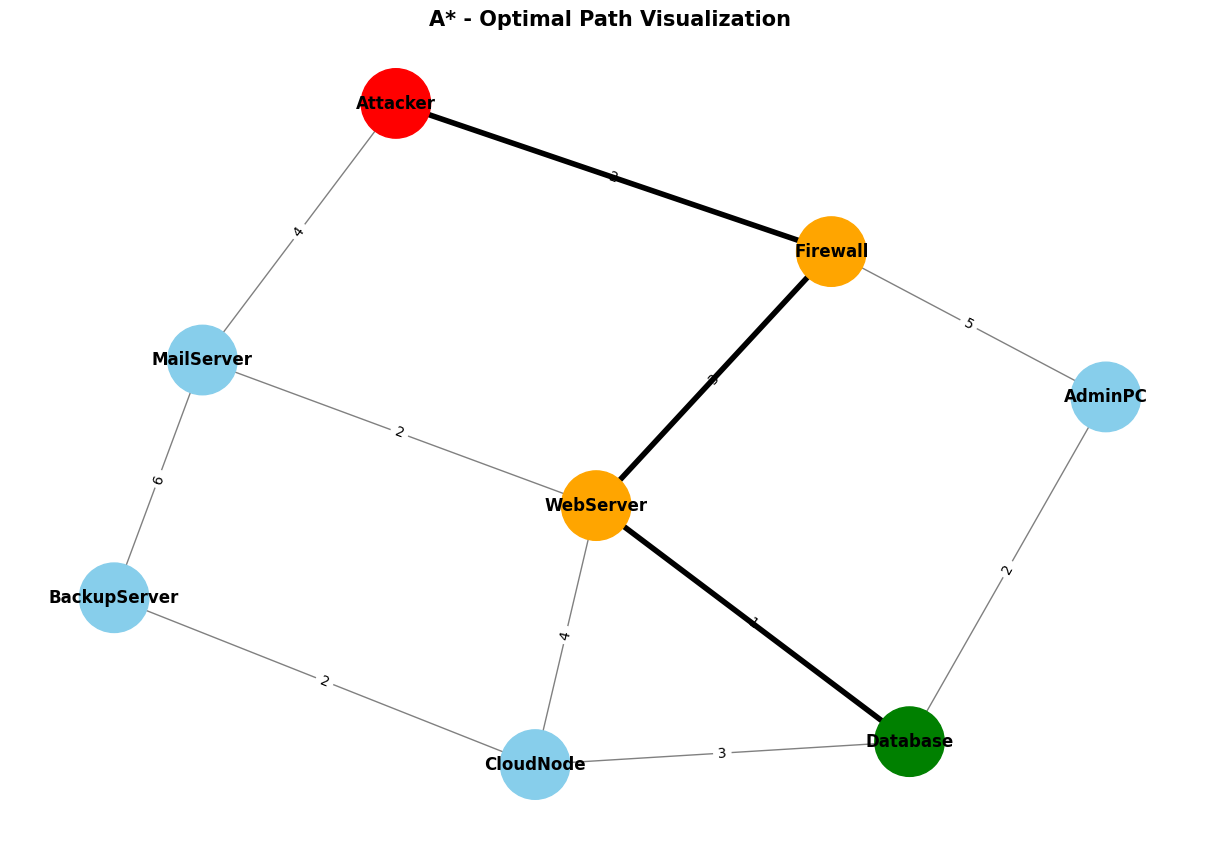

In [134]:
import networkx as nx
import matplotlib.pyplot as plt
# CREATE GRAPH
G = nx.Graph()

edges = [

    ("Attacker", "Firewall", 2),
    ("Attacker", "MailServer", 4),

    ("Firewall", "WebServer", 3),
    ("Firewall", "AdminPC", 5),

    ("MailServer", "WebServer", 2),
    ("MailServer", "BackupServer", 6),

    ("BackupServer", "CloudNode", 2),

    ("WebServer", "CloudNode", 4),
    ("WebServer", "Database", 1),

    ("CloudNode", "Database", 3),

    ("AdminPC", "Database", 2)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)
# DEFINE START & GOAL
start = "Attacker"
goal = "Database"

astar_path = [
    "Attacker",
    "Firewall",
    "WebServer",
    "Database"
]

# -----------------------------------
# GRAPH POSITIONING
# -----------------------------------

pos = nx.spring_layout(G, seed=42)

# -----------------------------------
# NODE COLORS
# -----------------------------------

node_colors = []

for node in G.nodes():

    if node == start:
        node_colors.append("red")

    elif node == goal:
        node_colors.append("green")

    elif node in astar_path:
        node_colors.append("orange")

    else:
        node_colors.append("skyblue")
# DRAW GRAPH
plt.figure(figsize=(12,8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2500,
    font_weight="bold",
    edge_color="gray"
)

# Edge labels
labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

# Highlight A* path
edges_path = list(zip(astar_path, astar_path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_path,
    width=4,
    edge_color="black"
)

plt.title(
    "A* - Optimal Path Visualization",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")
plt.show()

# UCS Implementation

---



In [135]:
def ucs():
    start_time = time.time()

    pq = [(0, start)]
    visited = set()
    parent = {}
    cost = {start: 0}
    nodes_expanded = 0

    while pq:
        g, node = heapq.heappop(pq)

        if node in visited:
            continue

        visited.add(node)
        nodes_expanded += 1

        if node == goal:
            break

        for n in G.neighbors(node):
            new_cost = g + G[node][n]['weight']

            if n not in cost or new_cost < cost[n]:
                cost[n] = new_cost
                parent[n] = node
                heapq.heappush(pq, (new_cost, n))

    path = []
    cur = goal
    while cur != start:
        path.append(cur)
        cur = parent[cur]
    path.append(start)
    path.reverse()

    return path, cost[goal], nodes_expanded, (time.time()-start_time)*1000

ucs_path, ucs_cost, ucs_nodes, ucs_time = ucs()

In [136]:
ucs_path, ucs_cost, ucs_nodes, ucs_time = ucs()

print("\n================ UCS RESULTS ================\n")

print(" Discovered Path:")
print(" -> ".join(ucs_path))
print("\n Total Cost:", ucs_cost)
print(" Nodes Expanded:", ucs_nodes)
print(" Execution Time (ms):", round(ucs_time, 4))


================ UCS RESULTS ================

 Discovered Path:
Attacker -> Firewall -> WebServer -> Database

 Total Cost: 6
📊 Nodes Expanded: 5
 Execution Time (ms): 0.0451


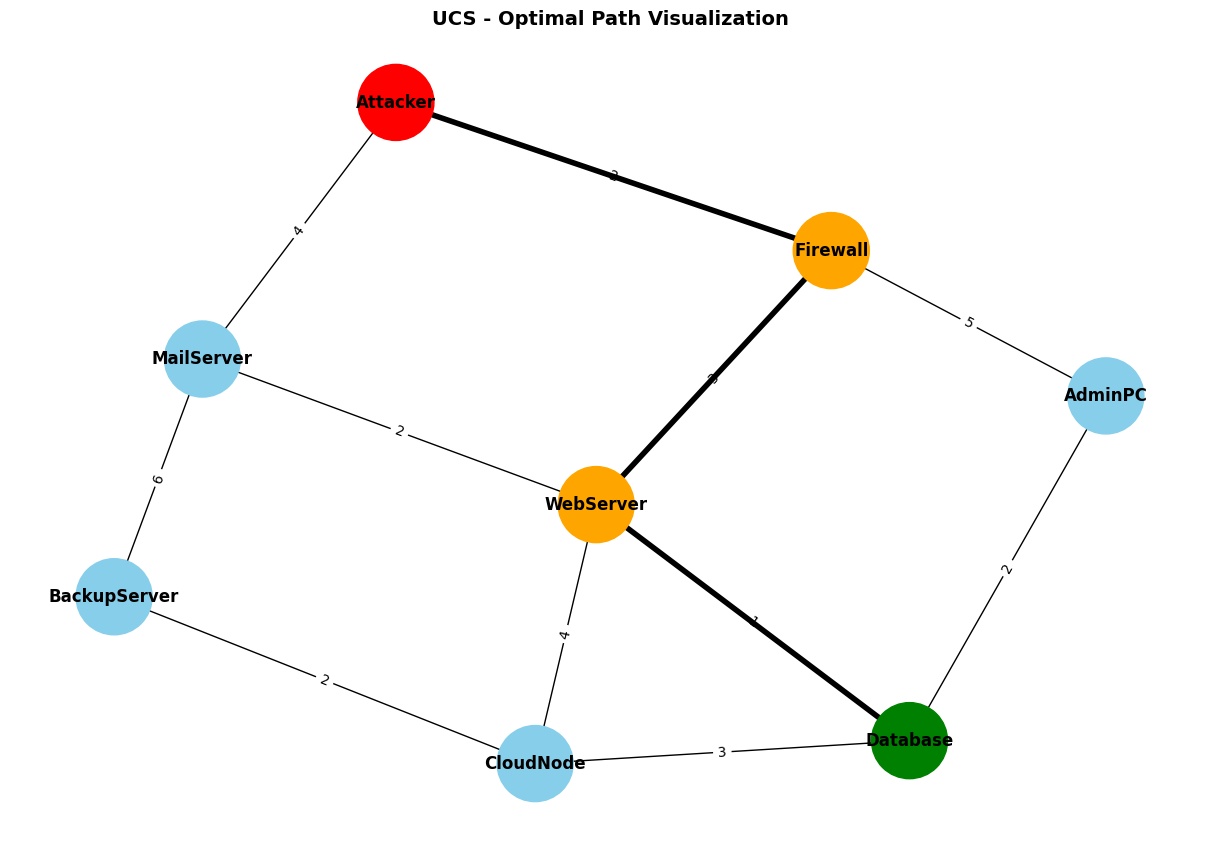

In [137]:
def draw_ucs_path():
    plt.figure(figsize=(12, 8))
     node_colors = []
    for node in G.nodes():
        if node == start:
            node_colors.append("red")      # Start
        elif node == goal:
            node_colors.append("green")    # Goal
        elif node in ucs_path:
            node_colors.append("orange")   # UCS path
        else:
            node_colors.append("skyblue")

    pos = nx.spring_layout(G, seed=42)

    # draw nodes + edges
    nx.draw(G, pos,
            with_labels=True,
            node_color=node_colors,
            node_size=3000,
            font_weight="bold")

    # edge weights
    labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    # highlight UCS path
    path_edges = list(zip(ucs_path, ucs_path[1:]))
    nx.draw_networkx_edges(G, pos,
                           edgelist=path_edges,
                           width=4,
                           edge_color="black")

    plt.title("UCS - Optimal Path Visualization", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


draw_ucs_path()

# Hill Climbing Algorithm

---



In [138]:
def hill_climbing():
    start_time = time.time()

    current = start
    path = [current]
    visited = set([current])
    nodes_expanded = 0

    while current != goal:
        nodes_expanded += 1

        neighbors = list(G.neighbors(current))

        next_node = None
        best_h = float("inf")

        for n in neighbors:
            if n not in visited and h[n] < best_h:
                best_h = h[n]
                next_node = n

        if next_node is None:
            break

        current = next_node
        visited.add(current)
        path.append(current)

    cost = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

    return path, cost, nodes_expanded, (time.time()-start_time)*1000

hc_path, hc_cost, hc_nodes, hc_time = hill_climbing()
hc_path, hc_cost, hc_nodes, hc_time = hill_climbing()

print("\n================ HILL CLIMBING RESULTS ================\n")
print(" Discovered Path:")
print(" -> ".join(hc_path))
print("\n Total Cost:", hc_cost)
print(" Nodes Expanded:", hc_nodes)
print(" Execution Time (ms):", round(hc_time, 4))


================ HILL CLIMBING RESULTS ================

 Discovered Path:
Attacker -> MailServer -> WebServer -> Database

 Total Cost: 7
 Nodes Expanded: 3
 Execution Time (ms): 0.0169


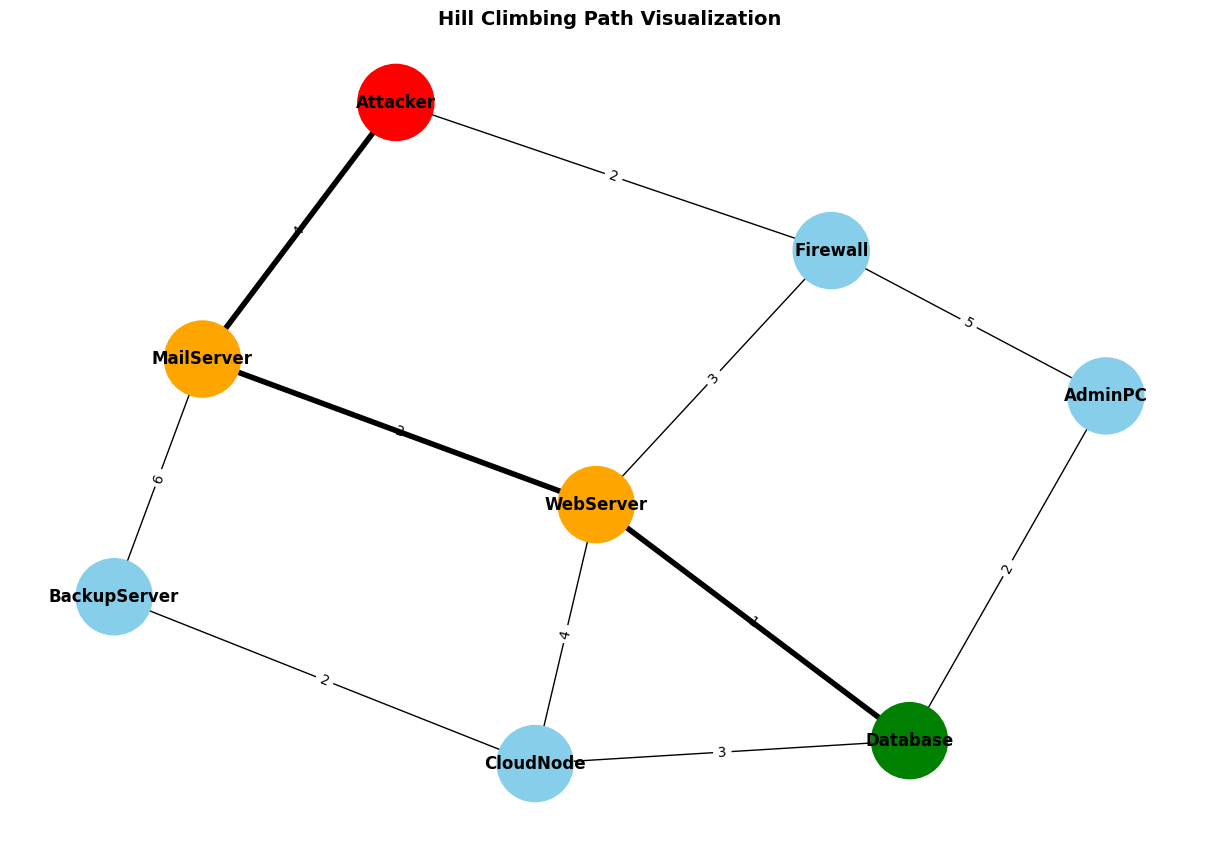

In [139]:
def draw_hc_path():
    plt.figure(figsize=(12, 8))

    node_colors = []
    for node in G.nodes():
        if node == start:
            node_colors.append("red")
        elif node == goal:
            node_colors.append("green")
        elif node in hc_path:
            node_colors.append("orange")
        else:
            node_colors.append("skyblue")

    pos = nx.spring_layout(G, seed=42)

    nx.draw(G, pos,
            with_labels=True,
            node_color=node_colors,
            node_size=3000,
            font_weight="bold")

    labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    path_edges = list(zip(hc_path, hc_path[1:]))
    nx.draw_networkx_edges(G, pos,
                           edgelist=path_edges,
                           width=4,
                           edge_color="black")

    plt.title("Hill Climbing Path Visualization", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()

draw_hc_path()

# Local Maxima

---



In [140]:
import networkx as nx
G = nx.Graph()

edges = [

    ("Attacker", "Firewall", 2),
    ("Attacker", "MailServer", 4),

    ("Firewall", "WebServer", 3),
    ("Firewall", "AdminPC", 5),

    ("MailServer", "WebServer", 2),
    ("MailServer", "BackupServer", 6),

    ("WebServer", "Database", 4),

    ("AdminPC", "Database", 7),

    ("BackupServer", "Database", 3)
]

# Add edges into graph
for u, v, w in edges:
    G.add_edge(u, v, weight=w)
heuristic = {

    "Attacker": 10,
    "Firewall": 8,

    # Local maxima node
    "MailServer": 2,

    # WORSE neighbors
    "WebServer": 9,
    "BackupServer": 7,

    "AdminPC": 6,

    # Goal
    "Database": 0
}
def hill_climbing(graph, start, goal, heuristic):

    current = start
    path = [current]
    visited = set()
while current != goal:

        visited.add(current)

        print(f"\n Current Node: {current}")
        print(f"Heuristic Value: {heuristic[current]}")

        neighbors = list(graph.neighbors(current))

        # Remove visited nodes
        neighbors = [n for n in neighbors if n not in visited]

        if not neighbors:

            print("\n FAILURE: No more neighbors available.")
            return path

        print("\n Neighbor Analysis:")

        best_neighbor = None
        best_h = heuristic[current]

        for neighbor in neighbors:

            h_value = heuristic[neighbor]

            print(f"   → {neighbor} : h = {h_value}")

            if h_value < best_h:

                best_h = h_value
                best_neighbor = neighbor
        if best_neighbor is None:

            print("\n⚠ LOCAL MAXIMA DETECTED ⚠")

            print(f"""
Hill Climbing FAILED because:

• Current node = {current}
• All neighboring nodes have WORSE heuristic values
• No better move exists

Algorithm becomes stuck at local optimum.
Goal node could not be reached.
""")

            return path

        print(f"\n Moving to Better Neighbor: {best_neighbor}")

        current = best_neighbor
        path.append(current)

    print("\n GOAL REACHED SUCCESSFULLY!")

    return path
hill_path = hill_climbing(G, "Attacker", "Database", heuristic)

print("\nFinal Path:", hill_path)


 HILL CLIMBING SEARCH STARTED 


 Current Node: Attacker
Heuristic Value: 10

 Neighbor Analysis:
   → Firewall : h = 8
   → MailServer : h = 2

 Moving to Better Neighbor: MailServer

 Current Node: MailServer
Heuristic Value: 2

 Neighbor Analysis:
   → WebServer : h = 9
   → BackupServer : h = 7

⚠ LOCAL MAXIMA DETECTED ⚠

Hill Climbing FAILED because:

• Current node = MailServer
• All neighboring nodes have WORSE heuristic values
• No better move exists

Algorithm becomes stuck at local optimum.
Goal node could not be reached.


Final Path: ['Attacker', 'MailServer']


# Graphical Representation


 HILL CLIMBING SEARCH STARTED 


📍 Current Node: Attacker
Heuristic Value: 10

🔎 Neighbor Analysis:
   → Firewall : h = 8
   → MailServer : h = 2

✅ Moving to Better Neighbor: MailServer

📍 Current Node: MailServer
Heuristic Value: 2

🔎 Neighbor Analysis:
   → WebServer : h = 9
   → BackupServer : h = 7

⚠ LOCAL MAXIMA DETECTED ⚠

Hill Climbing FAILED because:

• Current node = MailServer
• All neighboring nodes have WORSE heuristic values
• No better move exists

Algorithm becomes stuck at local optimum.
Goal node could not be reached.


Final Path: ['Attacker', 'MailServer']


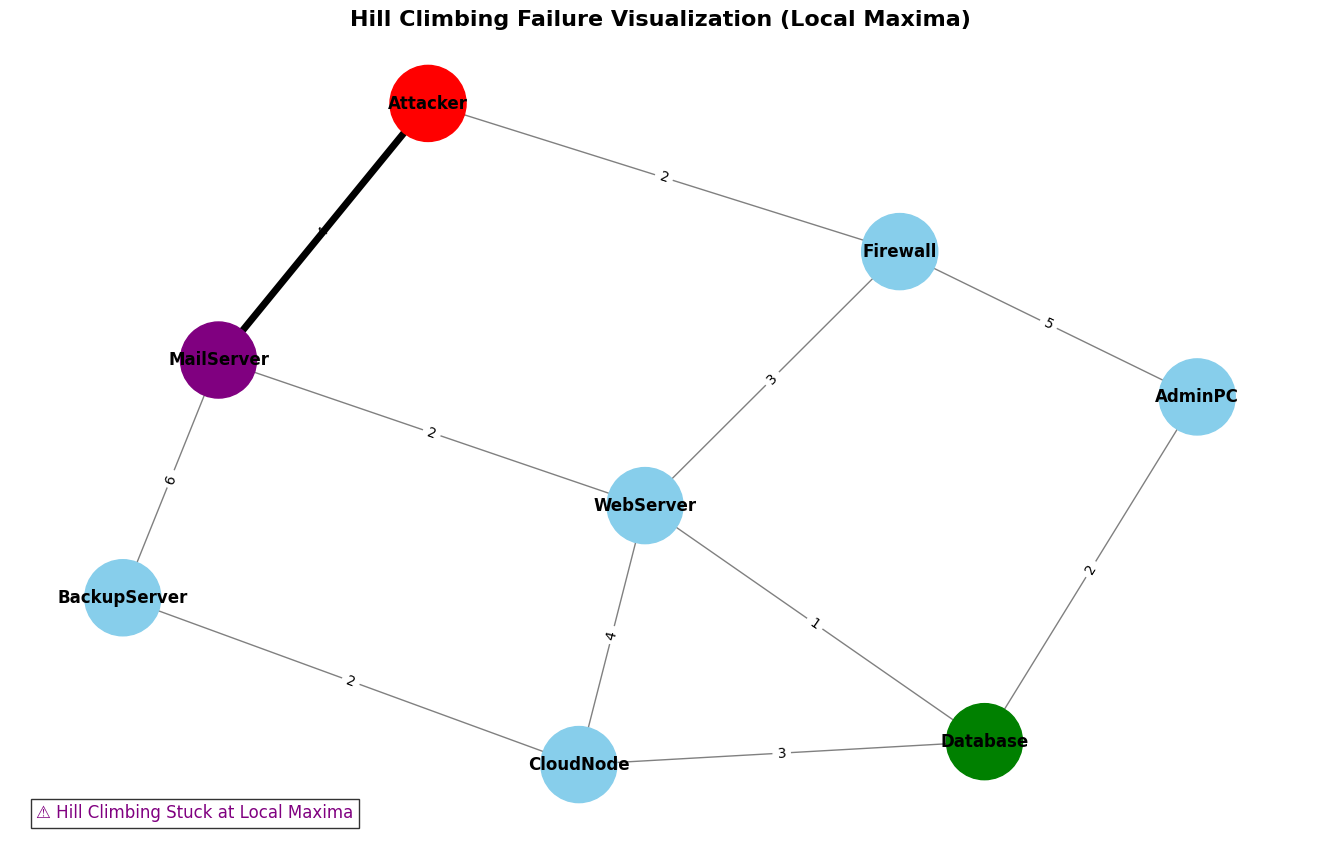

In [141]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()

edges = [

    ("Attacker", "Firewall", 2),
    ("Attacker", "MailServer", 4),

    ("Firewall", "WebServer", 3),
    ("Firewall", "AdminPC", 5),

    ("MailServer", "WebServer", 2),
    ("MailServer", "BackupServer", 6),

    ("BackupServer", "CloudNode", 2),

    ("WebServer", "CloudNode", 4),
    ("WebServer", "Database", 1),

    ("CloudNode", "Database", 3),

    ("AdminPC", "Database", 2)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)
heuristic = {

    "Attacker": 10,
    "Firewall": 8,

    # Local maxima node
    "MailServer": 2,

    # Worse neighbors
    "WebServer": 9,
    "BackupServer": 7,

    "CloudNode": 6,
    "AdminPC": 5,

    "Database": 0
}
def hill_climbing(graph, start, goal, heuristic):

    current = start
    path = [current]
    visited = set()
while current != goal:

        visited.add(current)

        print(f"\n📍 Current Node: {current}")
        print(f"Heuristic Value: {heuristic[current]}")

        neighbors = list(graph.neighbors(current))
        neighbors = [n for n in neighbors if n not in visited]

        print("\n🔎 Neighbor Analysis:")

        best_neighbor = None
        best_h = heuristic[current]

        for neighbor in neighbors:

            h_value = heuristic[neighbor]

            print(f"   → {neighbor} : h = {h_value}")

            if h_value < best_h:

                best_h = h_value
                best_neighbor = neighbor
        # LOCAL MAXIMA DETECTION
        if best_neighbor is None:

            print("\n⚠ LOCAL MAXIMA DETECTED ⚠")

            print(f"""
Hill Climbing FAILED because:

• Current node = {current}
• All neighboring nodes have WORSE heuristic values
• No better move exists

Algorithm becomes stuck at local optimum.
Goal node could not be reached.
""")

            return path, current

        print(f"\n✅ Moving to Better Neighbor: {best_neighbor}")

        current = best_neighbor
        path.append(current)

    print("\n🎯 GOAL REACHED SUCCESSFULLY!")

    return path, current

# -----------------------------------
# RUN ALGORITHM
# -----------------------------------

start = "Attacker"
goal = "Database"

hill_path, failed_node = hill_climbing(
    G,
    start,
    goal,
    heuristic
)

print("\nFinal Path:", hill_path)

# -----------------------------------
# VISUALIZATION
# -----------------------------------

plt.figure(figsize=(13,8))

pos = nx.spring_layout(G, seed=42)

# -----------------------------------
# NODE COLORS
# -----------------------------------

node_colors = []

for node in G.nodes():

    # Start node
    if node == start:
        node_colors.append("red")

    # Goal node
    elif node == goal:
        node_colors.append("green")

    # Failure node
    elif node == failed_node:
        node_colors.append("purple")

    # Traversed path
    elif node in hill_path:
        node_colors.append("orange")

    else:
        node_colors.append("skyblue")

# -----------------------------------
# DRAW GRAPH
# -----------------------------------

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3000,
    font_weight="bold",
    edge_color="gray"
)

# Edge labels
labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

# Highlight Hill Climbing Path
path_edges = list(zip(hill_path, hill_path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    width=5,
    edge_color="black"
)

# -----------------------------------
# TITLE
# -----------------------------------

plt.title(
    "Hill Climbing Failure Visualization (Local Maxima)",
    fontsize=16,
    fontweight="bold"
)

# Failure message on graph
plt.text(
    0.02,
    0.02,
    "⚠ Hill Climbing Stuck at Local Maxima",
    fontsize=12,
    color="purple",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.axis("off")
plt.show()

# MINIMAX ALGORITHM


 MINIMAX RESULT 
Optimal Value: 3
Best Path: Attacker → Firewall → Node3


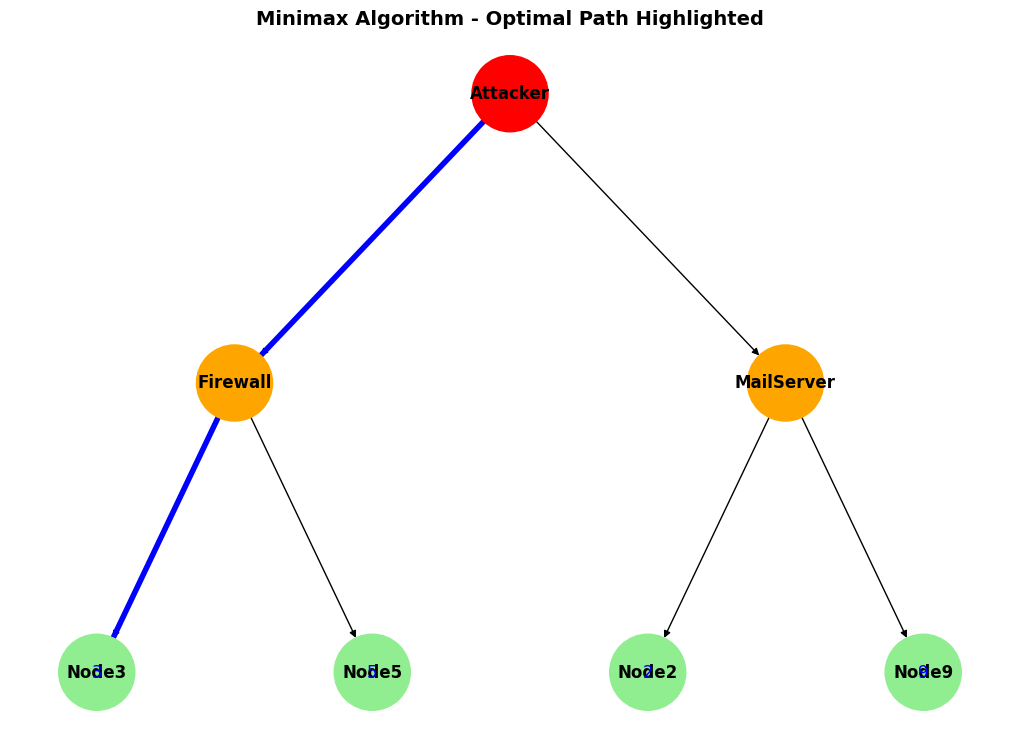

In [142]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------
# GAME TREE GRAPH
# -----------------------------------

G = nx.DiGraph()

edges = [

    ("Attacker", "Firewall"),
    ("Attacker", "MailServer"),

    ("Firewall", "Node3"),
    ("Firewall", "Node5"),

    ("MailServer", "Node2"),
    ("MailServer", "Node9")
]

G.add_edges_from(edges)

# Terminal values
values = {
    "Node3": 3,
    "Node5": 5,
    "Node2": 2,
    "Node9": 9
}

# -----------------------------------
# MINIMAX WITH PATH TRACKING
# -----------------------------------

def minimax(node, maximizingPlayer):

    # Terminal node
    if node in values:
        return values[node], [node]

    children = list(G.successors(node))

    # MAX PLAYER (Attacker)
    if maximizingPlayer:

        best_value = -float("inf")
        best_path = []

        for child in children:

            val, path = minimax(child, False)

            if val > best_value:
                best_value = val
                best_path = [node] + path

        return best_value, best_path

    # MIN PLAYER (Defender)
    else:

        best_value = float("inf")
        best_path = []

        for child in children:

            val, path = minimax(child, True)

            if val < best_value:
                best_value = val
                best_path = [node] + path

        return best_value, best_path


# -----------------------------------
# RUN MINIMAX
# -----------------------------------

result, best_path = minimax("Attacker", True)

print("\n==============================")
print(" MINIMAX RESULT ")
print("==============================")

print("Optimal Value:", result)
print("Best Path:", " → ".join(best_path))


# -----------------------------------
# VISUALIZATION
# -----------------------------------

plt.figure(figsize=(10,7))

pos = {

    "Attacker": (0,4),

    "Firewall": (-2,2),
    "MailServer": (2,2),

    "Node3": (-3,0),
    "Node5": (-1,0),

    "Node2": (1,0),
    "Node9": (3,0)
}

# Node colors
node_colors = []

for node in G.nodes():

    if node == "Attacker":
        node_colors.append("red")

    elif node in ["Firewall", "MailServer"]:
        node_colors.append("orange")

    else:
        node_colors.append("lightgreen")

# Draw full graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color=node_colors,
    font_weight="bold",
    arrows=True
)

# Terminal values on nodes
labels = {node: str(values[node]) for node in values}

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_color="blue"
)

# -----------------------------------
# HIGHLIGHT BEST PATH (BLUE)
# -----------------------------------

best_edges = list(zip(best_path, best_path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=best_edges,
    edge_color="blue",
    width=4
)

plt.title("Minimax Algorithm - Optimal Path Highlighted", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

# ALPHA-BETA PRUNING



RESULT: 3
PRUNED EDGES: [('MailServer', 'Node9')]


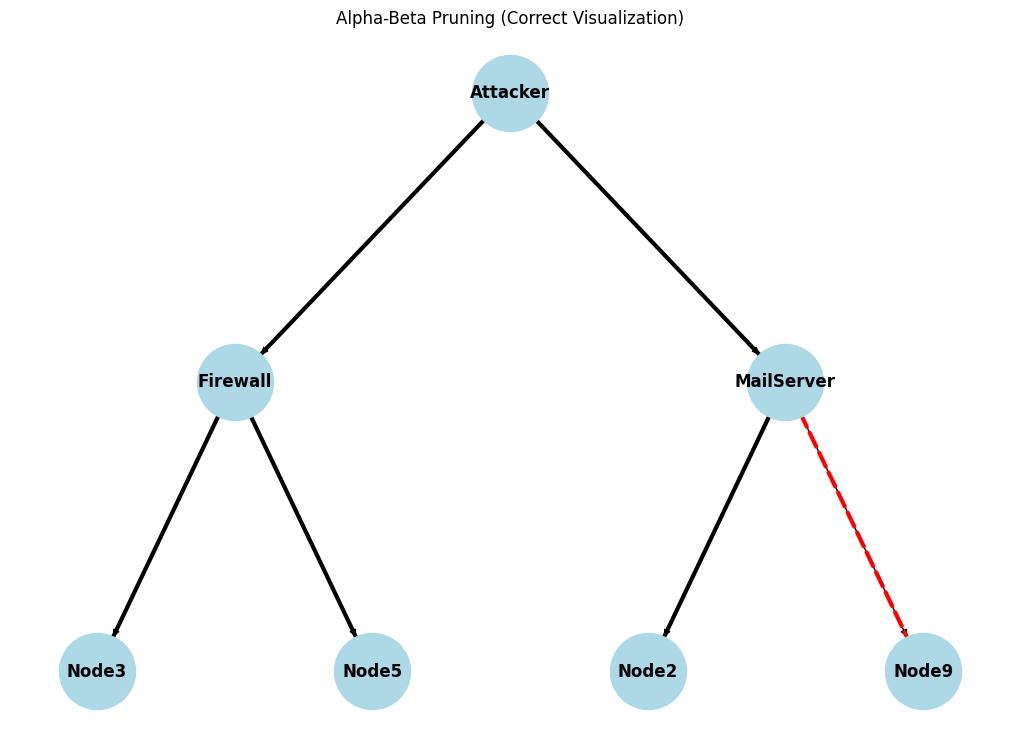

In [143]:
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------
# GAME TREE
# -----------------------------------

G = nx.DiGraph()

edges = [

    ("Attacker", "Firewall"),
    ("Attacker", "MailServer"),

    ("Firewall", "Node3"),
    ("Firewall", "Node5"),

    ("MailServer", "Node2"),
    ("MailServer", "Node9")
]

G.add_edges_from(edges)

values = {
    "Node3": 3,
    "Node5": 5,
    "Node2": 2,
    "Node9": 9
}

# =====================================================
# TRACKING
# =====================================================

visited_edges = []
pruned_edges = []

# -----------------------------------
# ALPHA-BETA FUNCTION
# -----------------------------------

def alphabeta(node, depth, alpha, beta, maximizingPlayer):

    if node in values:
        return values[node]

    children = list(G.successors(node))

    if maximizingPlayer:

        value = -float("inf")

        for i, child in enumerate(children):

            visited_edges.append((node, child))

            value = max(
                value,
                alphabeta(child, depth+1, alpha, beta, False)
            )

            alpha = max(alpha, value)

            # ❌ PRUNING OCCURS
            if alpha >= beta:

                for remaining in children[i+1:]:
                    pruned_edges.append((node, remaining))

                break

        return value

    else:

        value = float("inf")

        for i, child in enumerate(children):

            visited_edges.append((node, child))

            value = min(
                value,
                alphabeta(child, depth+1, alpha, beta, True)
            )

            beta = min(beta, value)

            # ❌ PRUNING OCCURS
            if beta <= alpha:

                for remaining in children[i+1:]:
                    pruned_edges.append((node, remaining))

                break

        return value

# -----------------------------------
# RUN
# -----------------------------------

result = alphabeta(
    "Attacker",
    0,
    -float("inf"),
    float("inf"),
    True
)

print("\nRESULT:", result)
print("PRUNED EDGES:", pruned_edges)

# -----------------------------------
# VISUALIZATION
# -----------------------------------

plt.figure(figsize=(10,7))

pos = {

    "Attacker": (0,4),
    "Firewall": (-2,2),
    "MailServer": (2,2),
    "Node3": (-3,0),
    "Node5": (-1,0),
    "Node2": (1,0),
    "Node9": (3,0)
}

# Base graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_weight="bold"
)

# Edge labels (values)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={}
)

# -----------------------------------
# VISITED PATH (BLACK)
# -----------------------------------

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=visited_edges,
    edge_color="black",
    width=3
)

# -----------------------------------
# PRUNED PATH (RED DASHED)
# -----------------------------------

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=pruned_edges,
    edge_color="red",
    style="dashed",
    width=3
)

plt.title("Alpha-Beta Pruning (Correct Visualization)")
plt.axis("off")
plt.show()


# Output and Empirical Analysis

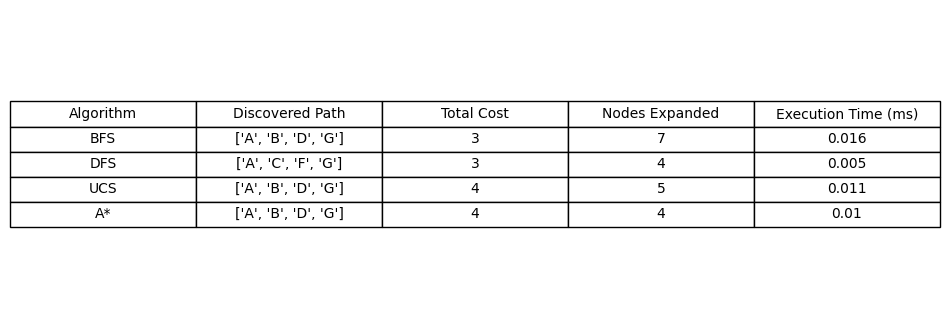

In [153]:
import time
import heapq
from collections import deque
import matplotlib.pyplot as plt

# Example graph (adjacency list with costs)
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'D': 2, 'E': 5},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 2},
    'F': {'G': 5},
    'G': {}
}

def bfs(start, goal):
    start_time = time.time()
    queue = deque([(start, [start])])
    visited = set()
    nodes_expanded = 0
    while queue:
        node, path = queue.popleft()
        nodes_expanded += 1
        if node == goal:
            return path, len(path)-1, nodes_expanded, (time.time()-start_time)*1000
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append((neighbor, path + [neighbor]))
    return None

def dfs(start, goal):
    start_time = time.time()
    stack = [(start, [start])]
    visited = set()
    nodes_expanded = 0
    while stack:
        node, path = stack.pop()
        nodes_expanded += 1
        if node == goal:
            return path, len(path)-1, nodes_expanded, (time.time()-start_time)*1000
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                stack.append((neighbor, path + [neighbor]))
    return None

def ucs(start, goal):
    start_time = time.time()
    pq = [(0, start, [start])]
    visited = set()
    nodes_expanded = 0
    while pq:
        cost, node, path = heapq.heappop(pq)
        nodes_expanded += 1
        if node == goal:
            return path, cost, nodes_expanded, (time.time()-start_time)*1000
        if node not in visited:
            visited.add(node)
            for neighbor, edge_cost in graph[node].items():
                heapq.heappush(pq, (cost+edge_cost, neighbor, path+[neighbor]))
    return None

def heuristic(node, goal):
    return abs(ord(goal) - ord(node))

def astar(start, goal):
    start_time = time.time()
    pq = [(0+heuristic(start, goal), 0, start, [start])]
    visited = set()
    nodes_expanded = 0
    while pq:
        f, cost, node, path = heapq.heappop(pq)
        nodes_expanded += 1
        if node == goal:
            return path, cost, nodes_expanded, (time.time()-start_time)*1000
        if node not in visited:
            visited.add(node)
            for neighbor, edge_cost in graph[node].items():
                g = cost + edge_cost
                h = heuristic(neighbor, goal)
                heapq.heappush(pq, (g+h, g, neighbor, path+[neighbor]))
    return None

# Run all algorithms
algorithms = {
    "BFS": bfs,
    "DFS": dfs,
    "UCS": ucs,
    "A*": astar
}

results = []
for name, algo in algorithms.items():
    path, cost, expanded, exec_time = algo('A', 'G')
    results.append([name, str(path), cost, expanded, round(exec_time, 3)])

# Create 2D table with matplotlib
headers = ["Algorithm", "Discovered Path", "Total Cost", "Nodes Expanded", "Execution Time (ms)"]

fig, ax = plt.subplots(figsize=(12, 4))  # Increase figure size for wider table
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=results, colLabels=headers, loc='center', cellLoc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 1.5)  # Increase scaling for wider cells

# Optionally adjust specific column widths
for key, cell in table.get_celld().items():
    cell.set_width(0.2)  # Increase width for all cells

plt.show()
